# Redes Neurais Convolucionais

## Entendendo a Operação de Convolução

Vamos aplicar a operação de convolução com diferentes kernels em imagens para entender que a operação de convolução é capaz de extrair características de uma determinada imagem de entrada. Para isso, vamos utilizar a biblioteca `opencv`.

Inicialmente vamos importar a imagem `lena.png`:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('./assets/lena.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

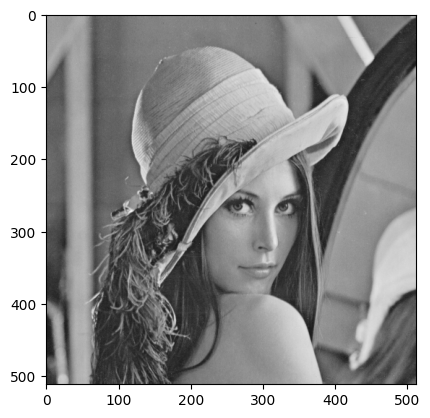

In [3]:
plt.imshow(img)

O primeiro kernel destaca as bordas (kernel Laplaciano):

 $$
            W = \begin{bmatrix}
            0 & 1 & 0 \\
            1 & -4 & 1 \\
            0 & 1 & 0
            \end{bmatrix}
$$

In [4]:
K1 = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
], dtype=np.float32)

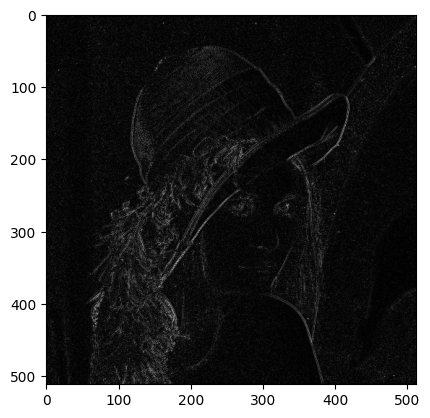

In [5]:
filtrada   = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=K1)
filtrada   = np.abs(filtrada)
edge_img   = cv2.normalize(filtrada, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(edge_img)

O segundo kernel aumenta a nitidez de uma imagem:

 $$
            W = \begin{bmatrix}
            0 & -1 & 0 \\
            -1 & 5 & -1 \\
            0 & -1 & 0
            \end{bmatrix}
            $$

In [6]:
K2 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

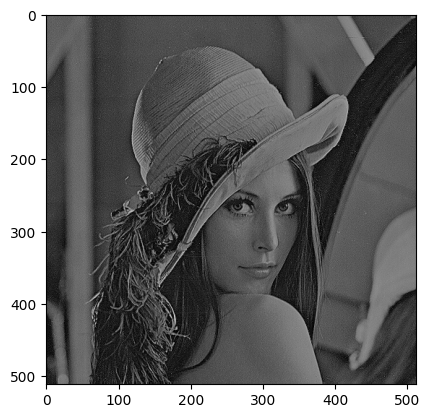

In [7]:
filtrada   = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=K2)
filtrada   = np.abs(filtrada)
sharp_img  = cv2.normalize(filtrada, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(sharp_img)

## Rede Neural Convolucional em Pytorch

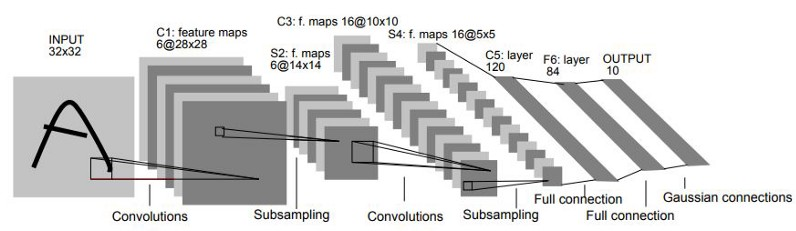

In [37]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import random_split

In [38]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1307], std=[0.3081])
])

In [39]:
full_train_dataset = MNIST(root="data", train=True,  download=True, transform=transform)
test_dataset       = MNIST(root="data", train=False, download=True, transform=transform)

In [40]:
val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
)

print(f"Treino:    {len(train_dataset)} amostras")
print(f"Validação: {len(val_dataset)} amostras")
print(f"Teste:     {len(test_dataset)} amostras")

Treino:    48000 amostras
Validação: 12000 amostras
Teste:     10000 amostras


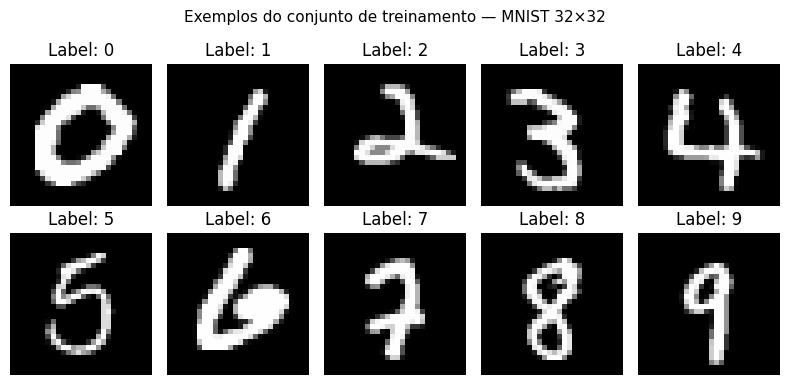

In [43]:
targets = full_train_dataset.targets.numpy()

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for digit, ax in enumerate(axes.flat):
    idx = np.random.choice(np.where(targets == digit)[0])
    ax.imshow(full_train_dataset.data[idx], cmap='gray')
    ax.set_title(f"Label: {digit}")
    ax.axis('off')
plt.suptitle("Exemplos do conjunto de treinamento — MNIST 32×32", fontsize=11)
plt.tight_layout()
plt.show()

In [51]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=8, pin_memory=True)

In [52]:
class LeNet5(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1,   out_channels=6,   kernel_size=5),   # → 6@28×28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                         # → 6@14×14
            nn.Conv2d(in_channels=6,   out_channels=16,  kernel_size=5),   # → 16@10×10
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                         # →  16@5×5 = 16x5x5 = 400
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                                 # 16×5×5 = 400
            nn.Linear(400, 120), nn.ReLU(),                               # C5: 120
            nn.Linear(120, 84),  nn.ReLU(),                               # F6: 84
            nn.Linear(84, num_classes),                                   # OUTPUT: 10
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.feature_extractor(x))

O `MaxPool2d` tem `stide = 2` pois não deve haver sobreposição entre as sucessivas janelas para o cálculo do `MaxPool2d`. Assim, a janela deve avançar exatamente a quantidade de elementos que ela possui. 

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [54]:
model  = LeNet5().to(device)

In [55]:
optimizer     = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion     = nn.CrossEntropyLoss()
epochs        = 50
patience      = 5

best_val_loss = float("inf")
best_weights  = None
patience_count = 0

In [56]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, epochs + 1):
    #── Treinamento ──────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(X)
        train_correct += (logits.argmax(dim=1) == y).sum().item()
    
    # Calcular o train_loss e o train_acc
    train_loss  = train_loss/len(train_dataset)
    train_acc   = train_correct/len(train_dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #── Validação ──────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits      = model(X)
            val_loss   += criterion(logits, y).item() * len(X)
            val_correct += (logits.argmax(dim=1) == y).sum().item()
    
    # Calcular o val_loss e val_acc
    val_loss  = val_loss/len(val_dataset)
    val_acc   = val_correct / len(val_dataset)  
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print (verificar o processo de treinamento)
    print(f"Epoch {epoch:2d}/{epochs} "
          f"| train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} "
          f"| val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

    #── Earlying Stop ──────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_weights   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
        print(f" ✔ val_loss melhorou → {best_val_loss:.6f}")
    else:
        patience_count += 1
        print(f" ✘ sem melhora há {patience_count}/{patience} épocas")
        if patience_count >= patience:
            print(f"\nEarly stopping acionado na época {epoch}.")
            break

# Recuperar os pesos salvos
model.load_state_dict(best_weights)
print("Melhores pesos restaurados.")


Epoch  1/50 | train_loss: 0.2684 train_acc: 0.9162 | val_loss: 0.0928 val_acc: 0.9694
 ✔ val_loss melhorou → 0.092757
Epoch  2/50 | train_loss: 0.0741 train_acc: 0.9771 | val_loss: 0.0605 val_acc: 0.9820
 ✔ val_loss melhorou → 0.060514
Epoch  3/50 | train_loss: 0.0519 train_acc: 0.9837 | val_loss: 0.0564 val_acc: 0.9821
 ✔ val_loss melhorou → 0.056360
Epoch  4/50 | train_loss: 0.0404 train_acc: 0.9873 | val_loss: 0.0517 val_acc: 0.9839
 ✔ val_loss melhorou → 0.051711
Epoch  5/50 | train_loss: 0.0340 train_acc: 0.9890 | val_loss: 0.0501 val_acc: 0.9843
 ✔ val_loss melhorou → 0.050105
Epoch  6/50 | train_loss: 0.0279 train_acc: 0.9914 | val_loss: 0.0461 val_acc: 0.9867
 ✔ val_loss melhorou → 0.046103
Epoch  7/50 | train_loss: 0.0236 train_acc: 0.9924 | val_loss: 0.0516 val_acc: 0.9856
 ✘ sem melhora há 1/5 épocas
Epoch  8/50 | train_loss: 0.0200 train_acc: 0.9936 | val_loss: 0.0599 val_acc: 0.9832
 ✘ sem melhora há 2/5 épocas
Epoch  9/50 | train_loss: 0.0175 train_acc: 0.9944 | val_loss:

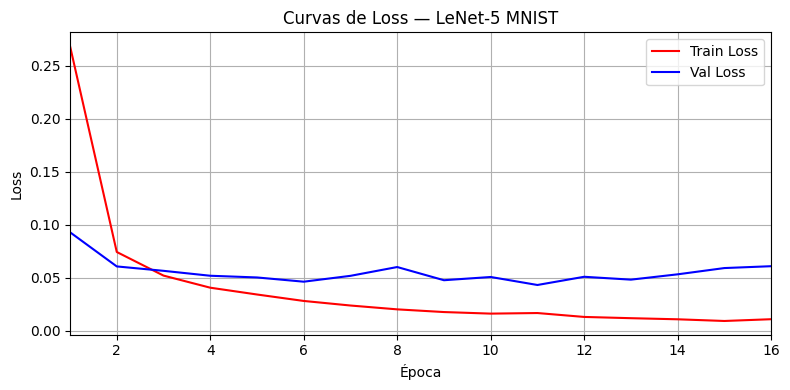

In [59]:
epochs_ran = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, train_losses, 'r', label="Train Loss")
plt.plot(epochs_ran, val_losses, 'b', label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curvas de Loss — LeNet-5 MNIST")
plt.legend()
plt.grid()
plt.xlim([1, len(train_losses)])
plt.tight_layout()
plt.show()

In [60]:
model.eval()
test_loss, test_correct = 0.0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits       = model(X)
        test_loss   += criterion(logits, y).item() * len(X)
        test_correct += (logits.argmax(dim=1) == y).sum().item()
test_loss  = test_loss/len(test_dataset)
test_acc   = test_correct / len(test_dataset)
print(f"\nTeste final | loss: {test_loss:.4f} | acc: {test_acc:.4f}")


Teste final | loss: 0.0336 | acc: 0.9897
